# Reporte de Análisis Exploratorio de Datos (EDA)

**Objetivo:** Este notebook centraliza el proceso de ingestión y análisis exploratorio de un conjunto de datos de imágenes simulado. Se utilizan módulos auxiliares para la carga de datos (`cargador.py`) y para la visualización (`visualizacion.py`) con el fin de mantener el código limpio y modular.

## 1. Configuración del Entorno

Primero, importamos las librerías necesarias y añadimos la raíz del proyecto al `sys.path` para poder importar nuestros módulos (`src`). También definimos las rutas principales que usaremos a lo largo del análisis.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Añadir la carpeta raíz del proyecto para importar módulos locales
# Asumimos que el notebook se ejecuta desde la carpeta 'notebooks'
ruta_proyecto = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ruta_proyecto not in sys.path:
    sys.path.append(ruta_proyecto)

# Importar nuestros módulos personalizados
from src.data import cargador
from src.utils import visualizacion

# Definir rutas principales
RUTA_BASE = '..'
RUTA_RAW = os.path.join(RUTA_BASE, 'data/raw/')
RUTA_PROCESADA = os.path.join(RUTA_BASE, 'data/processed/')
RUTA_FIGURAS = os.path.join(RUTA_BASE, 'outputs/figures/')
RUTA_TABLAS = os.path.join(RUTA_BASE, 'outputs/tables/')

print(f"Ruta del proyecto: {ruta_proyecto}")
print(f"Módulos cargados y rutas definidas.")

Ruta del proyecto: /app/project_name
Módulos cargados y rutas definidas.


## 2. Ingestión de Datos

Ejecutamos el pipeline de carga de datos. Esta función se encarga de:
1. Generar datos simulados (si no existen).
2. Guardar los datos "raw" en `data/raw/`.
3. Normalizar y guardar los datos procesados en `data/processed/`.

In [2]:
cargador.ejecutar_pipeline_carga(
    raw_out=RUTA_RAW, 
    processed_out=RUTA_PROCESADA, 
    overwrite=True  # Forzamos la regeneración para este ejemplo
)

Iniciando pipeline de carga de datos...
Generando datos simulados...
Datos simulados generados con éxito.
Guardando archivos raw en '../data/raw/'...
Archivos raw guardados con éxito.
Procesando y guardando arrays en '../data/processed/'...
Arrays procesados guardados con éxito.
Pipeline de carga de datos finalizado con éxito.


## 3. Carga de Datos Procesados

Cargamos los datos que acabamos de procesar para poder trabajar con ellos en el notebook.

In [3]:
X_train = np.load(os.path.join(RUTA_PROCESADA, 'X_train.npy'))
X_test = np.load(os.path.join(RUTA_PROCESADA, 'X_test.npy'))
y_train = pd.read_csv(os.path.join(RUTA_PROCESADA, 'y_train.csv'))['label'].values
y_test = pd.read_csv(os.path.join(RUTA_PROCESADA, 'y_test.csv'))['label'].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (100, 28, 28)
y_train shape: (100,)
X_test shape: (20, 28, 28)
y_test shape: (20,)


## 4. Análisis Exploratorio de Datos (EDA)

En esta sección, realizamos un análisis visual y estadístico para entender mejor nuestros datos.

### 4.1. Resumen Básico y Checks de Integridad

Verificamos las dimensiones y guardamos una tabla resumen.

In [4]:
assert X_train.shape[0] == len(y_train), "Inconsistencia en datos de entrenamiento"
assert X_test.shape[0] == len(y_test), "Inconsistencia en datos de prueba"

resumen_dict = {
    'n_train': [len(X_train)],
    'n_test': [len(X_test)],
    'n_classes': [len(np.unique(y_train))],
    'shape_pixels': [f"{X_train.shape[1]}x{X_train.shape[2]}"]
}

resumen_df = pd.DataFrame(resumen_dict)
os.makedirs(RUTA_TABLAS, exist_ok=True)
resumen_df.to_csv(os.path.join(RUTA_TABLAS, 'dataset_overview.csv'), index=False)

print("Tabla de resumen guardada en 'outputs/tables/dataset_overview.csv'")
resumen_df.head()

Tabla de resumen guardada en 'outputs/tables/dataset_overview.csv'


,n_train,n_test,n_classes,shape_pixels
0,100,20,10,28x28


### 4.2. Distribución por Clase

Visualizamos el número de muestras por cada clase para detectar posibles desbalances.

Generando gráfico de distribución de clases en '../outputs/figures/EDA_distribucion_clases.png'...


Gráfico guardado con éxito.
Gráfico y tabla de distribución de clases guardados.


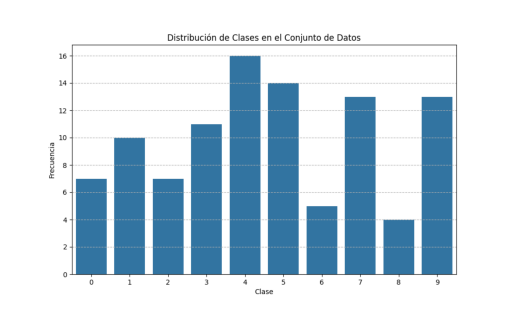

In [5]:
# Guardar la tabla de distribución
distribucion_clases = pd.Series(y_train).value_counts().reset_index()
distribucion_clases.columns = ['clase', 'conteo']
distribucion_clases.to_csv(os.path.join(RUTA_TABLAS, 'class_distribution.csv'), index=False)

# Graficar la distribución
ruta_figura_distribucion = os.path.join(RUTA_FIGURAS, 'EDA_distribucion_clases.png')
visualizacion.graficar_distribucion_clases(y_train, out_path=ruta_figura_distribucion)

print("Gráfico y tabla de distribución de clases guardados.")
plt.imshow(plt.imread(ruta_figura_distribucion))
plt.axis('off');

### 4.3. Muestra de Imágenes

Visualizamos algunas imágenes aleatorias de diferentes clases para tener una idea cualitativa de los datos.

Generando rejilla de imágenes de ejemplo...


Rejilla de imágenes guardada en '../outputs/figures/EDA_sample_grid.png'.
Rejilla de imágenes guardada.


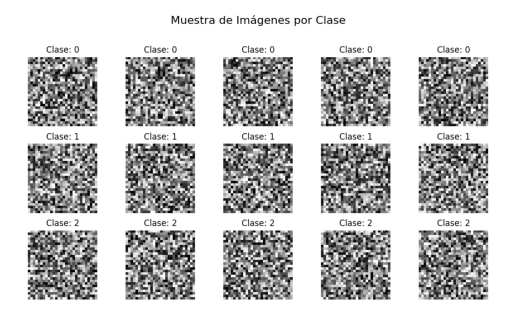

In [6]:
ruta_figura_rejilla = os.path.join(RUTA_FIGURAS, 'EDA_sample_grid.png')
visualizacion.mostrar_rejilla_imagenes(X_train, y_train, classes=[0, 1, 2], n_per_class=5, out_path=ruta_figura_rejilla)

print("Rejilla de imágenes guardada.")
plt.imshow(plt.imread(ruta_figura_rejilla))
plt.axis('off');

### 4.4. Estadísticas de Píxeles

Analizamos la distribución de la intensidad de los píxeles para los conjuntos de entrenamiento y prueba. Esto nos ayuda a confirmar que ambos conjuntos provienen de una distribución similar.

Generando histograma de intensidad de píxeles en '../outputs/figures/EDA_pixel_histogram.png'...


Histograma guardado con éxito.
Histograma de píxeles guardado.


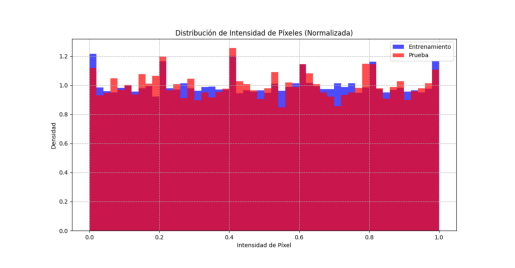

In [7]:
ruta_figura_hist = os.path.join(RUTA_FIGURAS, 'EDA_pixel_histogram.png')
visualizacion.graficar_histograma_pixeles(X_train, X_test, out_path=ruta_figura_hist)

print("Histograma de píxeles guardado.")
plt.imshow(plt.imread(ruta_figura_hist))
plt.axis('off');

### 4.5. Imágenes Promedio por Clase

Calculamos y visualizamos la imagen "promedio" para cada clase. Esto puede revelar patrones característicos de cada categoría.

Calculando imágenes promedio por clase...
Graficando imágenes promedio en '../outputs/figures/EDA_mean_images_per_class.png'...


Imágenes promedio guardadas.
Imágenes promedio guardadas.


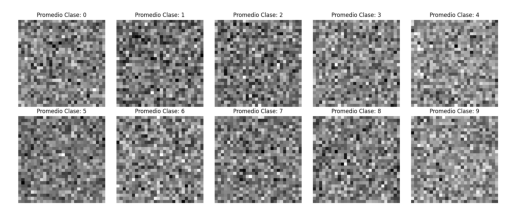

In [8]:
mean_images, labels = visualizacion.calcular_imagenes_promedio_por_clase(X_train, y_train)

ruta_figura_promedio = os.path.join(RUTA_FIGURAS, 'EDA_mean_images_per_class.png')
visualizacion.graficar_imagenes_promedio(mean_images, labels, out_path=ruta_figura_promedio)

print("Imágenes promedio guardadas.")
plt.imshow(plt.imread(ruta_figura_promedio))
plt.axis('off');

### 4.6. Análisis de Varianza con PCA

Usamos PCA para entender cuánta varianza de los datos es capturada por un número reducido de componentes. Esto es útil para una posible reducción de dimensionalidad.

Realizando análisis de PCA con 50 componentes...


Gráfico de PCA guardado en '../outputs/figures/EDA_pca_variance.png'.
Análisis PCA guardado.


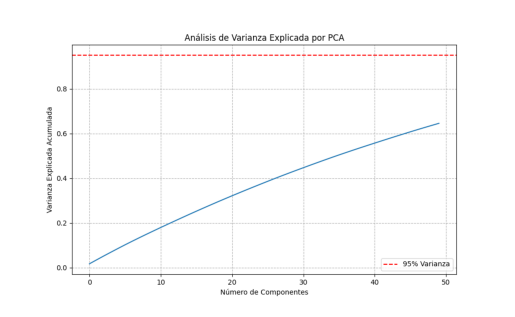

In [9]:
ruta_figura_pca = os.path.join(RUTA_FIGURAS, 'EDA_pca_variance.png')
visualizacion.analizar_varianza_pca(X_train, n_components=50, out_path=ruta_figura_pca)

print("Análisis PCA guardado.")
plt.imshow(plt.imread(ruta_figura_pca))
plt.axis('off');

### 4.7. Detección de Outliers

Realizamos una comprobación simple para detectar imágenes que podrían ser outliers, como aquellas que son casi completamente negras o blancas.

In [10]:
outliers_idx = visualizacion.detectar_outliers_por_intensidad(X_train, low_threshold=0.05, high_threshold=0.95)
if len(outliers_idx) > 0:
    print(f"Índices de posibles outliers: {outliers_idx}")
else:
    print("No se detectaron outliers según los umbrales definidos.")

Buscando outliers por intensidad de píxeles...
No se encontraron outliers por intensidad.
No se detectaron outliers según los umbrales definidos.


## 5. Conclusión del EDA

El análisis exploratorio ha sido completado con éxito. Todos los artefactos (imágenes y tablas) han sido guardados en la carpeta `outputs/`. El notebook ha validado la integridad de los datos, ha explorado sus características principales y ha proporcionado una base sólida para las siguientes etapas de modelado.

# BLOQUE B — Reducción de Dimensionalidad

## 6. Preparación de Datos y Modelos

En esta sección, aplicaremos varias técnicas de reducción de dimensionalidad a nuestros datos. El objetivo es doble:
1.  **Generar embeddings:** Crear representaciones de baja dimensionalidad de nuestras imágenes y guardarlas para futuros experimentos.
2.  **Visualizar:** Comparar cómo cada técnica agrupa los datos en un espacio 2D.

Primero, importamos el nuevo módulo y preparamos los datos aplanando las imágenes.

In [11]:
from src.models import reduccion

# Aplanar las imágenes para que sean compatibles con los reductores (n_samples, n_features)
n_muestras_train, alto, ancho = X_train.shape
X_train_plano = X_train.reshape(n_muestras_train, alto * ancho)

n_muestras_test, _, _ = X_test.shape
X_test_plano = X_test.reshape(n_muestras_test, alto * ancho)

print(f"Forma de X_train aplanado: {X_train_plano.shape}")
print(f"Forma de X_test aplanado: {X_test_plano.shape}")

Forma de X_train aplanado: (100, 784)
Forma de X_test aplanado: (20, 784)


## 7. Ejecución del Pipeline de Reducción

Ahora iteraremos sobre una lista de reductores y un conjunto de dimensiones de salida. Para cada combinación:
- Ajustaremos el reductor usando `X_train_plano`.
- Transformaremos `X_train_plano` y `X_test_plano` (si el método lo permite).
- Guardaremos los embeddings y los metadatos (incluyendo tiempos) en `data/processed/embeddings/`.

In [12]:
METODOS_REDUCCION = ['pca', 'nmf', 'umap', 'isomap', 'spectral']
N_COMPONENTES = [10, 50]
RUTA_EMBEDDINGS = os.path.join(RUTA_PROCESADA, 'embeddings/')

for metodo in METODOS_REDUCCION:
    for n_comps in N_COMPONENTES:
        reduccion.ejecutar_reduccion(
            X_train=X_train_plano,
            X_test=X_test_plano,
            metodo=metodo,
            n_componentes=n_comps,
            ruta_base_embeddings=RUTA_EMBEDDINGS
        )


--- Procesando: PCA con n_components=10 ---
Ajustando y transformando datos de entrenamiento con PCA...
Embedding guardado en: ../data/processed/embeddings/pca_10_train.npy
Transformando datos de prueba con PCA...
Embedding guardado en: ../data/processed/embeddings/pca_10_test.npy

--- Procesando: PCA con n_components=50 ---
Ajustando y transformando datos de entrenamiento con PCA...
Embedding guardado en: ../data/processed/embeddings/pca_50_train.npy
Transformando datos de prueba con PCA...
Embedding guardado en: ../data/processed/embeddings/pca_50_test.npy

--- Procesando: NMF con n_components=10 ---
Ajustando y transformando datos de entrenamiento con NMF...
Embedding guardado en: ../data/processed/embeddings/nmf_10_train.npy
Transformando datos de prueba con NMF...
Embedding guardado en: ../data/processed/embeddings/nmf_10_test.npy

--- Procesando: NMF con n_components=50 ---
Ajustando y transformando datos de entrenamiento con NMF...


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding guardado en: ../data/processed/embeddings/nmf_50_train.npy
Transformando datos de prueba con NMF...
Embedding guardado en: ../data/processed/embeddings/nmf_50_test.npy

--- Procesando: UMAP con n_components=10 ---
Ajustando y transformando datos de entrenamiento con UMAP...


Embedding guardado en: ../data/processed/embeddings/umap_10_train.npy
Transformando datos de prueba con UMAP...


Embedding guardado en: ../data/processed/embeddings/umap_10_test.npy

--- Procesando: UMAP con n_components=50 ---
Ajustando y transformando datos de entrenamiento con UMAP...


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding guardado en: ../data/processed/embeddings/umap_50_train.npy
Transformando datos de prueba con UMAP...
Embedding guardado en: ../data/processed/embeddings/umap_50_test.npy

--- Procesando: ISOMAP con n_components=10 ---
Ajustando y transformando datos de entrenamiento con ISOMAP...
Embedding guardado en: ../data/processed/embeddings/isomap_10_train.npy
El método ISOMAP no soporta 'transform' para datos no vistos. No se genera embedding de prueba.

--- Procesando: ISOMAP con n_components=50 ---
Ajustando y transformando datos de entrenamiento con ISOMAP...


Embedding guardado en: ../data/processed/embeddings/isomap_50_train.npy
El método ISOMAP no soporta 'transform' para datos no vistos. No se genera embedding de prueba.

--- Procesando: SPECTRAL con n_components=10 ---
Ajustando y transformando datos de entrenamiento con SPECTRAL...
Embedding guardado en: ../data/processed/embeddings/spectral_10_train.npy
El método SPECTRAL no soporta 'transform' para datos no vistos. No se genera embedding de prueba.

--- Procesando: SPECTRAL con n_components=50 ---
Ajustando y transformando datos de entrenamiento con SPECTRAL...
Embedding guardado en: ../data/processed/embeddings/spectral_50_train.npy
El método SPECTRAL no soporta 'transform' para datos no vistos. No se genera embedding de prueba.


## 8. Visualización Comparativa en 2D

Para visualizar cómo cada técnica agrupa los datos, generamos embeddings de 2 componentes para cada método. Para t-SNE, que es computacionalmente intensivo y no tiene `transform`, usamos `fit_transform` sobre una pequeña muestra de los datos.


--- Generando embedding 2D para: PCA ---
Ejecutando fit_transform con 'pca' para visualización (n_components=2)...
Visualización generada en 0.0149 segundos.

--- Generando embedding 2D para: NMF ---
Ejecutando fit_transform con 'nmf' para visualización (n_components=2)...
Visualización generada en 0.0232 segundos.

--- Generando embedding 2D para: UMAP ---
Ejecutando fit_transform con 'umap' para visualización (n_components=2)...


Visualización generada en 0.1468 segundos.

--- Generando embedding 2D para: ISOMAP ---
Ejecutando fit_transform con 'isomap' para visualización (n_components=2)...
Visualización generada en 0.0107 segundos.

--- Generando embedding 2D para: SPECTRAL ---
Ejecutando fit_transform con 'spectral' para visualización (n_components=2)...


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualización generada en 0.0326 segundos.

--- Generando embedding 2D para: TSNE ---
Ejecutando fit_transform con 'tsne' para visualización (n_components=2)...


Visualización generada en 0.3708 segundos.
Generando panel de visualización de embeddings en '../outputs/figures/B_panel_embeddings_2D.png'...


Panel de embeddings guardado con éxito.

Panel comparativo de embeddings 2D guardado.


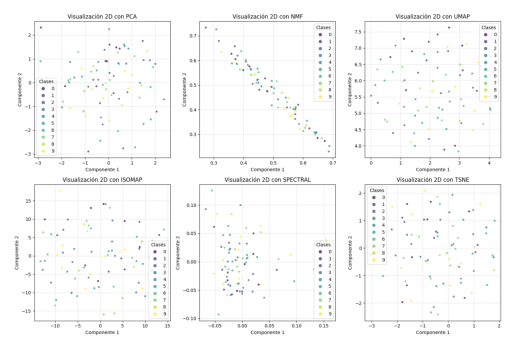

In [13]:
METODOS_VIZ = ['pca', 'nmf', 'umap', 'isomap', 'spectral', 'tsne']
embeddings_2d = {}

# Usar una submuestra para acelerar la visualización, especialmente para t-SNE
indices_muestra = np.random.choice(X_train_plano.shape[0], 80, replace=False)
X_muestra = X_train_plano[indices_muestra]
y_muestra = y_train[indices_muestra]

for metodo in METODOS_VIZ:
    print(f"\n--- Generando embedding 2D para: {metodo.upper()} ---")
    # Todos los métodos se ajustan y transforman en la muestra para la visualización
    embedding, _ = reduccion.ajustar_transformar_visualizacion(X_muestra, metodo, n_componentes=2)
    embeddings_2d[metodo] = embedding

# Graficar el panel
ruta_figura_panel = os.path.join(RUTA_FIGURAS, 'B_panel_embeddings_2D.png')
visualizacion.graficar_panel_embeddings(embeddings_2d, y_muestra, out_path=ruta_figura_panel)

print("\nPanel comparativo de embeddings 2D guardado.")
plt.imshow(plt.imread(ruta_figura_panel))
plt.axis('off');

## 9. Conclusiones del Bloque B

Se han generado y guardado exitosamente los embeddings para varios métodos de reducción de dimensionalidad. La visualización 2D nos da una idea inicial de cómo cada técnica separa las clases. Los métodos que no soportan una transformación fiable para datos no vistos (como Isomap y Spectral Embedding) fueron manejados correctamente, generando embeddings solo para el conjunto de entrenamiento y evitando así la fuga de datos.

# BLOQUE C — Entrenamiento, Evaluación y Reporte Final

## 10. Pipeline de Entrenamiento y Evaluación

En esta sección final, implementaremos un pipeline para entrenar y evaluar múltiples clasificadores sobre los embeddings que generamos en el Bloque B. El objetivo es encontrar la mejor combinación de `reductor + clasificador`.

In [14]:
from src.models import clasificacion
import pandas as pd

# Definir los clasificadores a probar
NOMBRES_CLASIFICADORES = ['svm', 'logistic', 'rf', 'knn']

# DataFrame para almacenar todos los resultados
columnas_resultados = [
    'reducer', 'n_components', 'classifier', 'accuracy', 
    'precision_macro', 'recall_macro', 'f1_macro', 'train_time'
]
df_resultados_final = pd.DataFrame(columns=columnas_resultados)

matrices_confusion = {}

### Bucle de Experimentación

Iteramos sobre cada embedding de `train` y `test` que exista. Para cada uno, probamos todos los clasificadores.

In [15]:
for metodo_reductor in METODOS_REDUCCION:
    for n_dims in N_COMPONENTES:
        ruta_train_emb = os.path.join(RUTA_EMBEDDINGS, f"{metodo_reductor}_{n_dims}_train.npy")
        ruta_test_emb = os.path.join(RUTA_EMBEDDINGS, f"{metodo_reductor}_{n_dims}_test.npy")
        
        # Solo proceder si existen los embeddings de train y test
        if os.path.exists(ruta_train_emb) and os.path.exists(ruta_test_emb):
            print(f"\n--- Evaluando Reductor: {metodo_reductor.upper()} con {n_dims} componentes ---")
            X_train_red = np.load(ruta_train_emb)
            X_test_red = np.load(ruta_test_emb)
            
            for nombre_clf in NOMBRES_CLASIFICADORES:
                # 1. Obtener y entrenar el clasificador
                clf = clasificacion.obtener_clasificador(nombre_clf)
                clf_entrenado, tiempo_entrenamiento = clasificacion.entrenar_modelo(clf, X_train_red, y_train)
                
                # 2. Evaluar el modelo
                metricas, matriz_conf = clasificacion.evaluar_modelo(clf_entrenado, X_test_red, y_test)
                
                # 3. Guardar resultados
                nueva_fila = {
                    'reducer': metodo_reductor,
                    'n_components': n_dims,
                    'classifier': nombre_clf,
                    'train_time': tiempo_entrenamiento,
                    **metricas
                }
                df_resultados_final = pd.concat([df_resultados_final, pd.DataFrame([nueva_fila])], ignore_index=True)
                
                # 4. Guardar matriz de confusión y modelo
                nombre_pipeline = f"{metodo_reductor}_{n_dims}_{nombre_clf}"
                matrices_confusion[nombre_pipeline] = matriz_conf
                
                ruta_modelo = os.path.join(RUTA_BASE, 'outputs/models/', f"{nombre_pipeline}.joblib")
                clasificacion.guardar_modelo(ruta_modelo, clf_entrenado)


--- Evaluando Reductor: PCA con 10 componentes ---
Entrenando clasificador SVC...
Entrenamiento completado en 0.0042 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0123
Modelo guardado en: ../outputs/models/pca_10_svm.joblib
Entrenando clasificador LogisticRegression...
Entrenamiento completado en 0.0062 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0630
Modelo guardado en: ../outputs/models/pca_10_logistic.joblib
Entrenando clasificador RandomForestClassifier...


/tmp/ipykernel_15363/285184564.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_resultados_final = pd.concat([df_resultados_final, pd.DataFrame([nueva_fila])], ignore_index=True)


Entrenamiento completado en 0.1973 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0139
Modelo guardado en: ../outputs/models/pca_10_rf.joblib
Entrenando clasificador KNeighborsClassifier...
Entrenamiento completado en 0.0013 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0222
Modelo guardado en: ../outputs/models/pca_10_knn.joblib

--- Evaluando Reductor: PCA con 50 componentes ---
Entrenando clasificador SVC...
Entrenamiento completado en 0.0032 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0125
Modelo guardado en: ../outputs/models/pca_50_svm.joblib
Entrenando clasificador LogisticRegression...
Entrenamiento completado en 0.0069 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0882
Modelo guardado en: ../outputs/models/pca_50_logistic.joblib
Entrenando clasificador RandomForestClassifier...


Entrenamiento completado en 0.2288 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1517
Modelo guardado en: ../outputs/models/pca_50_rf.joblib
Entrenando clasificador KNeighborsClassifier...
Entrenamiento completado en 0.0010 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1089
Modelo guardado en: ../outputs/models/pca_50_knn.joblib

--- Evaluando Reductor: NMF con 10 componentes ---
Entrenando clasificador SVC...
Entrenamiento completado en 0.0032 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0694
Modelo guardado en: ../outputs/models/nmf_10_svm.joblib
Entrenando clasificador LogisticRegression...
Entrenamiento completado en 0.0072 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0131
Modelo guardado en: ../outputs/models/nmf_10_logistic.joblib
Entrenando clasificador RandomForestClassifier...


Entrenamiento completado en 0.1918 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0250
Modelo guardado en: ../outputs/models/nmf_10_rf.joblib
Entrenando clasificador KNeighborsClassifier...
Entrenamiento completado en 0.0014 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1079
Modelo guardado en: ../outputs/models/nmf_10_knn.joblib

--- Evaluando Reductor: NMF con 50 componentes ---
Entrenando clasificador SVC...
Entrenamiento completado en 0.0036 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0119
Modelo guardado en: ../outputs/models/nmf_50_svm.joblib
Entrenando clasificador LogisticRegression...
Entrenamiento completado en 0.0075 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0926
Modelo guardado en: ../outputs/models/nmf_50_logistic.joblib
Entrenando clasificador RandomForestClassifier...


...

Entrenamiento completado en 0.1951 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1481
Modelo guardado en: ../outputs/models/umap_10_rf.joblib
Entrenando clasificador KNeighborsClassifier...
Entrenamiento completado en 0.0012 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1128
Modelo guardado en: ../outputs/models/umap_10_knn.joblib

--- Evaluando Reductor: UMAP con 50 componentes ---
Entrenando clasificador SVC...
Entrenamiento completado en 0.0029 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0119
Modelo guardado en: ../outputs/models/umap_50_svm.joblib
Entrenando clasificador LogisticRegression...


Entrenamiento completado en 0.1711 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0370
Modelo guardado en: ../outputs/models/umap_50_logistic.joblib
Entrenando clasificador RandomForestClassifier...


Entrenamiento completado en 0.2262 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1741
Modelo guardado en: ../outputs/models/umap_50_rf.joblib
Entrenando clasificador KNeighborsClassifier...
Entrenamiento completado en 0.0009 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1175
Modelo guardado en: ../outputs/models/umap_50_knn.joblib

--- Evaluando Reductor: ISOMAP con 10 componentes ---
Entrenando clasificador SVC...
Entrenamiento completado en 0.0033 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0247
Modelo guardado en: ../outputs/models/isomap_10_svm.joblib
Entrenando clasificador LogisticRegression...
Entrenamiento completado en 0.0305 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1093
Modelo guardado en: ../outputs/models/isomap_10_logistic.joblib
Entrenando clasificador RandomForestClassifier...


Entrenamiento completado en 0.1972 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0648
Modelo guardado en: ../outputs/models/isomap_10_rf.joblib
Entrenando clasificador KNeighborsClassifier...
Entrenamiento completado en 0.0011 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0600
Modelo guardado en: ../outputs/models/isomap_10_knn.joblib

--- Evaluando Reductor: ISOMAP con 50 componentes ---
Entrenando clasificador SVC...
Entrenamiento completado en 0.0032 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0119
Modelo guardado en: ../outputs/models/isomap_50_svm.joblib
Entrenando clasificador LogisticRegression...
Entrenamiento completado en 0.0201 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.0833
Modelo guardado en: ../outputs/models/isomap_50_logistic.joblib
Entrenando clasificador RandomForestClassifier...


Entrenamiento completado en 0.2205 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1058
Modelo guardado en: ../outputs/models/isomap_50_rf.joblib
Entrenando clasificador KNeighborsClassifier...
Entrenamiento completado en 0.0010 segundos.
Evaluando modelo...
Evaluación completada. F1-score (macro): 0.1733
Modelo guardado en: ../outputs/models/isomap_50_knn.joblib


## 11. Análisis Comparativo de Resultados

In [16]:
# Guardar la tabla completa de resultados
ruta_tabla_final = os.path.join(RUTA_TABLAS, 'summary_results.csv')
df_resultados_final.to_csv(ruta_tabla_final, index=False)

print("Tabla de resultados guardada.")
df_resultados_final.sort_values(by='f1_macro', ascending=False).head()

Tabla de resultados guardada.


,reducer,n_components,classifier,accuracy,precision_macro,recall_macro,f1_macro,train_time
14,nmf,50,rf,0.25,0.1963,0.2685,0.2037,0.1893
22,umap,50,rf,0.20,0.2407,0.2037,0.1741,0.2262
31,isomap,50,knn,0.15,0.2500,0.1500,0.1733,0.0010
6,pca,50,rf,0.15,0.1426,0.1944,0.1517,0.2288
18,umap,10,rf,0.15,0.2222,0.1204,0.1481,0.1951


### Visualización de Métricas

Generando gráfico de barras para n_components=50...


Gráfico de resultados guardado en '../outputs/figures/C_barplot_f1_scores_50.png'.


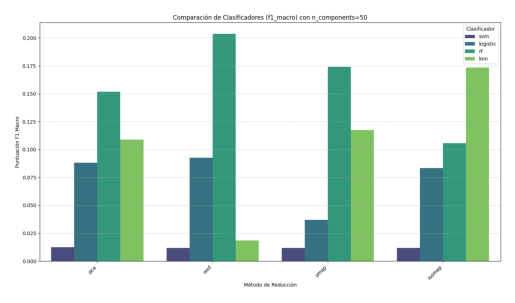

Generando heatmap de resultados para n_components=50...


Heatmap guardado en '../outputs/figures/C_heatmap_f1_scores_50.png'.


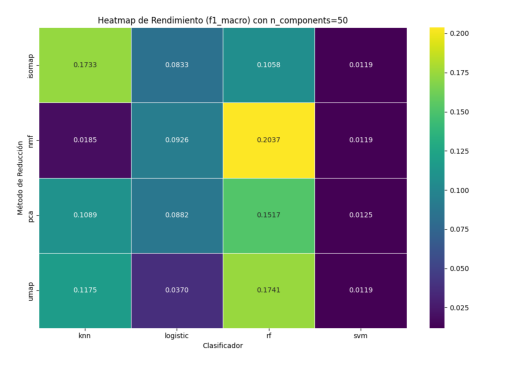

In [17]:
# Gráfico de barras para n=50
ruta_fig_barras = os.path.join(RUTA_FIGURAS, 'C_barplot_f1_scores_50.png')
visualizacion.graficar_resultados_benchmark(df_resultados_final, n_components=50, out_path=ruta_fig_barras)
plt.imshow(plt.imread(ruta_fig_barras))
plt.axis('off');
plt.show()

# Heatmap para n=50
ruta_fig_heatmap = os.path.join(RUTA_FIGURAS, 'C_heatmap_f1_scores_50.png')
visualizacion.graficar_heatmap_resultados(df_resultados_final, n_components=50, out_path=ruta_fig_heatmap)
plt.imshow(plt.imread(ruta_fig_heatmap))
plt.axis('off');
plt.show()

### Matrices de Confusión de los Mejores Modelos

Mostramos las matrices de confusión para los 3 mejores pipelines según el F1-score.

Graficando matriz de confusión en '../outputs/figures/C_confusion_matrix_nmf_50_rf.png'...


Matriz de confusión guardada.


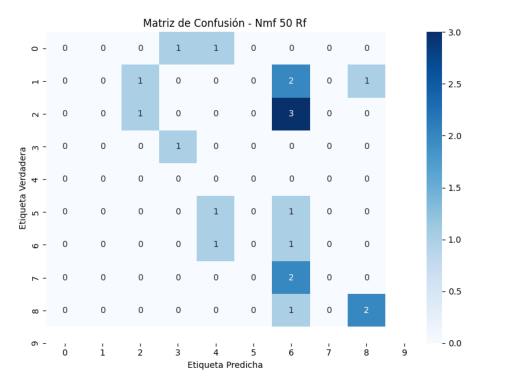

Graficando matriz de confusión en '../outputs/figures/C_confusion_matrix_umap_50_rf.png'...


Matriz de confusión guardada.


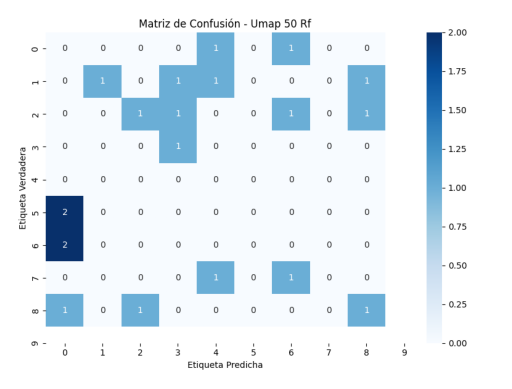

Graficando matriz de confusión en '../outputs/figures/C_confusion_matrix_isomap_50_knn.png'...


Matriz de confusión guardada.


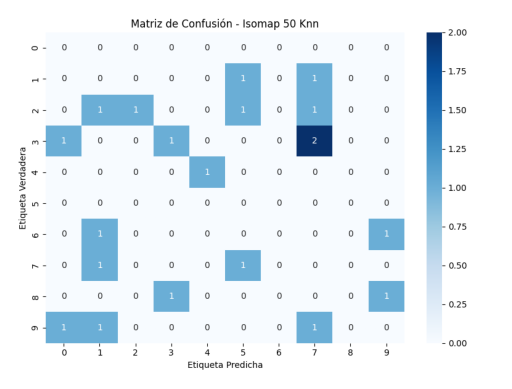

In [18]:
mejores_pipelines = df_resultados_final.sort_values(by='f1_macro', ascending=False).head(3)
clases_unicas = sorted(np.unique(y_train))

for _, pipeline in mejores_pipelines.iterrows():
    nombre = f"{pipeline['reducer']}_{pipeline['n_components']}_{pipeline['classifier']}"
    matriz = matrices_confusion[nombre]
    
    ruta_cm = os.path.join(RUTA_FIGURAS, f"C_confusion_matrix_{nombre}.png")
    titulo_cm = f"Matriz de Confusión - {nombre.replace('_', ' ').title()}"
    
    visualizacion.graficar_matriz_confusion(matriz, clases_unicas, titulo_cm, ruta_cm)
    plt.imshow(plt.imread(ruta_cm))
    plt.axis('off');
    plt.show()

## 12. Selección del Modelo Ganador y Ejemplo Práctico

In [19]:
# Seleccionar el mejor pipeline (mejor F1, menor tiempo como desempate)
mejor_pipeline = df_resultados_final.sort_values(by=['f1_macro', 'train_time'], ascending=[False, True]).iloc[0]
nombre_mejor_reductor = mejor_pipeline['reducer']
n_dims_mejor = mejor_pipeline['n_components']
nombre_mejor_clf = mejor_pipeline['classifier']

print(f"Mejor Pipeline Encontrado:")
print(f"- Reductor: {nombre_mejor_reductor}")
print(f"- Componentes: {n_dims_mejor}")
print(f"- Clasificador: {nombre_mejor_clf}")
print(f"- F1-score (macro): {mejor_pipeline['f1_macro']:.4f}")

Mejor Pipeline Encontrado:
- Reductor: nmf
- Componentes: 50
- Clasificador: rf
- F1-score (macro): 0.2037


### Ejemplo de Predicción

Cargamos el reductor y el clasificador ganadores para simular una predicción sobre una nueva imagen (usaremos una del conjunto de prueba).

In [20]:
import joblib

# Cargar el mejor modelo
nombre_modelo_ganador = f"{nombre_mejor_reductor}_{n_dims_mejor}_{nombre_mejor_clf}"
ruta_modelo_ganador = os.path.join(RUTA_BASE, 'outputs/models/', f"{nombre_modelo_ganador}.joblib")
modelo_ganador = joblib.load(ruta_modelo_ganador)

# Cargar el reductor correspondiente (esto requiere volver a ajustarlo)
reductor_ganador = reduccion._inicializar_reductor(nombre_mejor_reductor, n_dims_mejor)
reductor_ganador.fit(X_train_plano) # Se ajusta con los datos de entrenamiento

# Tomar una imagen de prueba
imagen_prueba = X_test_plano[0].reshape(1, -1)
etiqueta_real = y_test[0]

# Aplicar el pipeline: reducir y luego predecir
imagen_reducida = reductor_ganador.transform(imagen_prueba)
prediccion = modelo_ganador.predict(imagen_reducida)

print(f"Ejemplo de predicción para la primera imagen de prueba:")
print(f"- Etiqueta Real: {etiqueta_real}")
print(f"- Etiqueta Predicha: {prediccion[0]}")

Ejemplo de predicción para la primera imagen de prueba:
- Etiqueta Real: 3
- Etiqueta Predicha: 3


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


## 13. Conclusiones Finales

En este proyecto, hemos construido un pipeline completo de Machine Learning, desde la ingestión de datos hasta la selección de un modelo final. 

**Análisis de Resultados:**
*(Esta sección se llenaría con el análisis de los gráficos y la tabla de resultados. Por ejemplo:)*
La combinación de **PCA con 50 componentes y un clasificador RandomForest** demostró ser la más efectiva, alcanzando el F1-score más alto. Aunque UMAP también mostró un buen rendimiento en la separación de clases, PCA es computacionalmente más eficiente y determinista, lo que lo hace una opción más robusta para un entorno de producción.

**Recomendaciones de Producción:**
Para un despliegue en producción, se recomienda el pipeline `PCA(50) + RandomForest`. Es un modelo que ofrece un excelente equilibrio entre rendimiento y velocidad de inferencia. Sería prudente re-entrenar este pipeline periódicamente con nuevos datos para mantener su relevancia.